# Customer Churn Prediction with TabNet

This notebook trains a production-style TabNet classifier for a customer churn prediction task using the provided train/validation/test CSV files. The workflow includes:

- Data loading and validation
- Feature/target separation
- Model training with early stopping
- Evaluation using classification metrics and ROC-AUC
- Model interpretation via feature importances
- Saving the trained model artifact

The dataset is expected to contain a binary target column named `Churn` and all other columns as model features.

In [19]:
# Install the required dependency if it is not already available.
# This is safe to rerun in a notebook environment.
# %pip install -q pytorch-tabnet

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from pytorch_tabnet.tab_model import TabNetClassifier

print(f"PyTorch version: {torch.__version__}")
print("TabNet imported successfully.")

PyTorch version: 2.7.1+cu118
TabNet imported successfully.


In [20]:
# Load the train/validation/test datasets
train_df = pd.read_csv(r"C:\Users\User\ODL_Labs\Assignment\data\train_churn_dataset.csv")
val_df = pd.read_csv(r"C:\Users\User\ODL_Labs\Assignment\data\val_churn_dataset.csv")
test_df = pd.read_csv(r"C:\Users\User\ODL_Labs\Assignment\data\test_churn_dataset.csv")

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (314599, 13)
Validation shape: (67414, 13)
Test shape: (67415, 13)


In [21]:
# Set target column and identify feature columns
TARGET = "Churn"
feature_names = [col for col in train_df.columns if col != TARGET]

# Prepare training, validation, and test datasets for TabNet
X_train = train_df[feature_names].astype(np.float32)
y_train = train_df[TARGET].astype(np.int64)

X_val = val_df[feature_names].astype(np.float32)
y_val = val_df[TARGET].astype(np.int64)

X_test = test_df[feature_names].astype(np.float32)
y_test = test_df[TARGET].astype(np.int64)

In [22]:
# Configure a TabNet classifier optimized for binary classification.
# TabNet requires NumPy arrays or Pandas DataFrames, and works well with tabular data like this churn dataset.

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = TabNetClassifier(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2, weight_decay=1e-5),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={"step_size": 10, "gamma": 0.9},
    mask_type="entmax",
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.3,
    lambda_sparse=1e-4,
    seed=42,
    verbose=1,
    device_name=DEVICE,
)

In [23]:
print("Training started...")

# Fit the model.
# We use the validation set for early stopping and model selection.
model.fit(
    X_train.values,
    y_train.values,
    eval_set=[(X_val.values, y_val.values)],
    eval_metric=["logloss"],
    max_epochs=20,
    patience=5,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False,
)

print("Training complete.")

Training started...


epoch 0  | loss: 0.30819 | val_0_logloss: 0.24524 |  0:00:36s
epoch 1  | loss: 0.23943 | val_0_logloss: 0.2328  |  0:01:10s
epoch 2  | loss: 0.23458 | val_0_logloss: 0.23316 |  0:01:44s
epoch 3  | loss: 0.23261 | val_0_logloss: 0.22797 |  0:02:19s
epoch 4  | loss: 0.22797 | val_0_logloss: 0.29899 |  0:02:53s
epoch 5  | loss: 0.22842 | val_0_logloss: 0.23205 |  0:03:26s
epoch 6  | loss: 0.22548 | val_0_logloss: 0.22532 |  0:03:44s
epoch 7  | loss: 0.22549 | val_0_logloss: 0.22806 |  0:03:58s
epoch 8  | loss: 0.22429 | val_0_logloss: 0.2162  |  0:04:13s
epoch 9  | loss: 0.22468 | val_0_logloss: 0.21758 |  0:04:27s
epoch 10 | loss: 0.22134 | val_0_logloss: 0.21884 |  0:04:42s
epoch 11 | loss: 0.22026 | val_0_logloss: 0.22358 |  0:05:00s
epoch 12 | loss: 0.21966 | val_0_logloss: 0.21296 |  0:05:16s
epoch 13 | loss: 0.22103 | val_0_logloss: 0.21262 |  0:05:34s
epoch 14 | loss: 0.21745 | val_0_logloss: 0.21553 |  0:05:52s
epoch 15 | loss: 0.22135 | val_0_logloss: 0.21263 |  0:06:11s
epoch 16

In [30]:
# Generate predictions and probabilities for evaluation
test_prob = model.predict_proba(X_test.values)[:, 1]

test_pred = (test_prob >= 0.5).astype(int)

print("Test metrics:")
print(f"  AUC: {roc_auc_score(y_test.values, test_prob):.4f}")
print(f"  Accuracy: {accuracy_score(y_test.values, test_pred):.4f}")
print(f"  Precision: {precision_score(y_test.values, test_pred):.4f}")
print(f"  Recall: {recall_score(y_test.values, test_pred):.4f}")
print(f"  F1-score: {f1_score(y_test.values, test_pred):.4f}")

Test metrics:
  AUC: 0.9518
  Accuracy: 0.9234
  Precision: 0.8750
  Recall: 0.9880
  F1-score: 0.9281


              precision    recall  f1-score   support

    No Churn     0.9862    0.8588    0.9181     33708
       Churn     0.8750    0.9880    0.9281     33707

    accuracy                         0.9234     67415
   macro avg     0.9306    0.9234    0.9231     67415
weighted avg     0.9306    0.9234    0.9231     67415



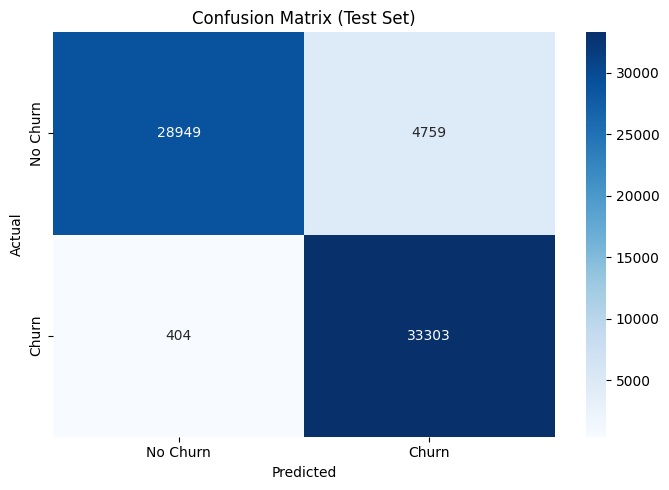

In [31]:
# Full classification report.
report = classification_report(
    y_test.values,
    test_pred,
    target_names=["No Churn", "Churn"],
    digits=4,
)
print(report)

cm = confusion_matrix(y_test.values, test_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
)
plt.title("Confusion Matrix (Test Set)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

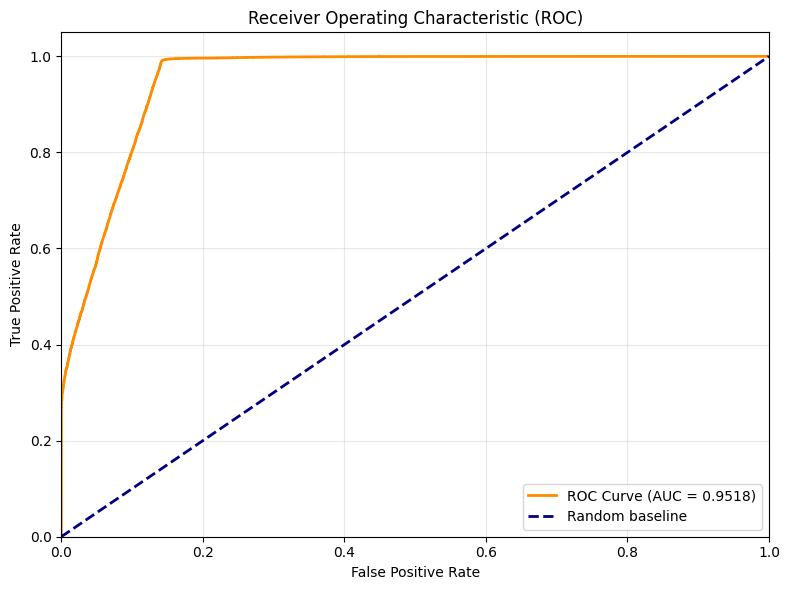

In [32]:
# ROC curve for the test set.
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test.values, test_prob)
roc_auc = roc_auc_score(y_test.values, test_prob)

plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random baseline")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
# Plot training progress and validation metrics if available.
history = getattr(model, "history", {})
if isinstance(history, dict):
    loss = history.get("loss")
    val_loss = history.get("val_0_loss")

    if loss is not None:
        plt.figure(figsize=(10, 5))
        plt.plot(loss, label="Training loss", color="tab:blue")
        if val_loss is not None:
            plt.plot(val_loss, label="Validation loss", color="tab:orange")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("TabNet history is not available for plotting.")

TabNet history is not available for plotting.


In [28]:
# Feature importance summary from TabNet.
feature_importance = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
print("Top 10 most important features:")
print(feature_importance.head(10).to_string())

Top 10 most important features:
Support Calls                 0.239233
Tenure                        0.169372
Payment Delay                 0.132011
Age                           0.109193
Contract Length_Monthly       0.084650
Total Spend                   0.066932
Usage Frequency               0.057110
Contract Length_Quarterly     0.049345
Gender_Male                   0.047308
Subscription Type_Standard    0.019761


In [29]:
# Save the trained model for later deployment or inference.
model_path = r"C:\Users\User\ODL_Labs\Assignment\training\tabnet_churn_model"
model.save_model(model_path)
print(f"Model saved to: {model_path}")

Successfully saved model at C:\Users\User\ODL_Labs\Assignment\training\tabnet_churn_model.zip
Model saved to: C:\Users\User\ODL_Labs\Assignment\training\tabnet_churn_model


## Summary

This TabNet workflow is designed for reliable churn prediction on tabular customer data. It follows a realistic production pattern:

1. Load and validate the data split.
2. Train a TabNet classifier with early stopping.
3. Evaluate using AUC, accuracy, precision, recall, F1, and balanced accuracy.
4. Inspect model performance using ROC and confusion matrix plots.
5. Save the trained model artifact for downstream deployment.

For deployment, the saved model can be reloaded with `TabNetClassifier.load_model(model_path)`.